# KTP Associate Pre-Interview Data Analysis Exercise

## Question 2: What insights can be gained from the available data?

This notebook highlights the main trends, patterns, and potential relationships visible in the accelerated stability data.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

cols = ['start_date', 'pull_date', 'set_down_day', 'exposure_days', 'oven', 'temp_c', 'rh', 'analyst', 'assay_s1', 'assay_s2', 'imp092_s1', 'imp092_s2', 'imp123_s1', 'imp123_s2']
lot_a_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.185, 8.119, 0.288, 0.282, 0.074, 0.074], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 11.184, 10.702, 0.246, 0.215, 0.134, 0.136], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.1, 12.238, 0.222, 0.222, 0.191, 0.189], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.518, 11.095, 0.651, 0.673, 0.167, 0.171], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.813, 11.294, 0.527, 0.541, 0.176, 0.176], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.72, 11.687, 0.314, 0.289, 0.165, 0.164], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.286, 8.409, 0.51, 0.472, 0.125, 0.126], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.519, 10.643, 0.527, 0.564, 0.186, 0.184], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.34, 12.46, 0.184, 0.178, 0.198, 0.2], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.533, 12.545, 0.165, 0.165, 0.207, 0.211], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 11.912, 12.063, 0.269, 0.273, 0.194, 0.193], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 12.172, 12.178, 0.179, 0.165, 0.25, 0.246], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.281, 12.215, 0.282, 0.279, 0.297, 0.295], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.946, 11.323, 0.535, 0.544, 0.474, 0.478], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.197, 11.597, 0.573, 0.451, 0.38, 0.39], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.951, 11.909, 0.379, 0.384, 0.615, 0.621], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.039, 12.41, 0.136, 0.132, 0.386, 0.382], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.006, 12.464, 0.223, 0.211, 0.506, 0.512], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 12.15, 11.877, 0.302, 0.289, 0.748, 0.746], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.79, 12.808, 0, 0, 0.082, 0.068]]
lot_b_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.439, 7.993, 0.304, 0.287, 0.113, 0.113], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 10.463, 10.676, 0.279, 0.213, 0.207, 0.205], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.278, 12.321, 0.253, 0.241, 0.312, 0.316], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.054, 11.439, 0.737, 0.7, 0.242, 0.238], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.504, 11.413, 0.575, 0.558, 0.287, 0.291], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.653, 11.998, 0.343, 0.328, 0.271, 0.269], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.677, 8.406, 0.472, 0.491, 0.174, 0.174], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.33, 10.621, 0.52, 0.465, 0.25, 0.252], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.171, 12.14, 0.186, 0.186, 0.305, 0.309], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.308, 12.387, 0.166, 0.17, 0.309, 0.307], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 12.206, 11.714, 0.288, 0.296, 0.31, 0.316], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 11.83, 11.734, 0.19, 0.169, 0.332, 0.326], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.419, 12.228, 0.291, 0.301, 0.424, 0.432], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.829, 10.606, 0.583, 0.531, 0.546, 0.542], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.32, 11.16, 0.607, 0.576, 0.517, 0.515], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.677, 12.051, 0.454, 0.426, 0.773, 0.771], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.307, 12.258, 0.134, 0.135, 0.482, 0.48], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.137, 12.155, 0.236, 0.232, 0.658, 0.65], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 11.733, 12.053, 0.314, 0.312, 0.888, 0.882], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.493, 12.72, 0, 0, 0.143, 0.143]]
df_a = pd.DataFrame(lot_a_rows, columns=cols)
df_b = pd.DataFrame(lot_b_rows, columns=cols)
df_a['lot'] = 'A014'
df_b['lot'] = 'B025'
df = pd.concat([df_a, df_b], ignore_index=True)
for col_name in ['start_date', 'pull_date']:
    df[col_name] = pd.to_datetime(df[col_name], errors='coerce')
for metric_name, pair_cols in {'assay':['assay_s1','assay_s2'], 'imp092':['imp092_s1','imp092_s2'], 'imp123':['imp123_s1','imp123_s2']}.items():
    df[metric_name + '_mean'] = df[pair_cols].mean(axis=1)
df['is_control'] = df['exposure_days'].eq(0)
analysis_df = df.loc[~df['is_control']].copy()
for col_name in ['temp_c', 'rh', 'exposure_days']:
    analysis_df[col_name] = pd.to_numeric(analysis_df[col_name], errors='coerce')
analysis_df.head()


,start_date,pull_date,set_down_day,exposure_days,oven,temp_c,rh,analyst,assay_s1,assay_s2,imp092_s1,imp092_s2,imp123_s1,imp123_s2,lot,assay_mean,imp092_mean,imp123_mean,is_control
0,2025-12-18,2026-01-08,0,21,Oven 2,70,11,RG,8.185,8.119,0.288,0.282,0.074,0.074,A014,8.1520,0.2850,0.074,False
1,2025-12-18,2026-01-08,0,21,Oven 4,65,25,SS,11.184,10.702,0.246,0.215,0.134,0.136,A014,10.9430,0.2305,0.135,False
2,2025-12-18,2026-01-08,0,21,Oven 1,50,64,SS,12.100,12.238,0.222,0.222,0.191,0.189,A014,12.1690,0.2220,0.190,False
3,2025-12-18,2026-01-08,0,21,Oven 3,60,80,CM,11.518,11.095,0.651,0.673,0.167,0.171,A014,11.3065,0.6620,0.169,False
4,2025-12-18,2026-01-08,0,21,Oven 3,60,42,CM,11.813,11.294,0.527,0.541,0.176,0.176,A014,11.5535,0.5340,0.176,False


In [2]:
control_df = df.loc[df['is_control']].copy()
control_map = control_df.set_index('lot')[['assay_mean','imp092_mean','imp123_mean']].to_dict('index')
for metric_name in ['assay', 'imp092', 'imp123']:
    analysis_df[metric_name + '_delta_vs_control'] = analysis_df.apply(lambda row: row[metric_name + '_mean'] - control_map[row['lot']][metric_name + '_mean'], axis=1)
summary_by_lot = analysis_df.groupby('lot')[['assay_mean','imp092_mean','imp123_mean']].agg(['mean','min','max']).round(3)
correlation_df = analysis_df[['exposure_days','temp_c','rh','assay_mean','imp092_mean','imp123_mean']].corr().round(3)
summary_by_lot
correlation_df


,exposure_days,temp_c,rh,assay_mean,imp092_mean,imp123_mean
exposure_days,1.000,-0.358,-0.233,-0.436,0.203,-0.842
temp_c,-0.358,1.000,-0.274,-0.551,0.414,0.351
rh,-0.233,-0.274,1.000,0.335,0.052,0.357
assay_mean,-0.436,-0.551,0.335,1.000,-0.373,0.411
imp092_mean,0.203,0.414,0.052,-0.373,1.000,-0.012
imp123_mean,-0.842,0.351,0.357,0.411,-0.012,1.000


In [3]:
feature_cols = ['exposure_days', 'temp_c', 'rh']
model_rows = []
for lot_name in sorted(analysis_df['lot'].unique()):
    lot_view = analysis_df[analysis_df['lot'] == lot_name]
    for response_name in ['assay_mean', 'imp092_mean', 'imp123_mean']:
        fit_reg = LinearRegression()
        fit_reg.fit(lot_view[feature_cols], lot_view[response_name])
        pred_vals = fit_reg.predict(lot_view[feature_cols])
        model_rows.append({'lot': lot_name, 'response': response_name, 'r2': round(r2_score(lot_view[response_name], pred_vals), 3), 'coef_days': round(fit_reg.coef_[0], 4), 'coef_temp': round(fit_reg.coef_[1], 4), 'coef_rh': round(fit_reg.coef_[2], 4)})
model_df = pd.DataFrame(model_rows)
model_df


,lot,response,r2,coef_days,coef_temp,coef_rh
0,A014,assay_mean,0.757,-0.1157,-0.1468,-0.0034
1,A014,imp092_mean,0.471,0.0116,0.0170,0.0027
2,A014,imp123_mean,0.835,-0.0167,0.0057,0.0021
3,B025,assay_mean,0.782,-0.1112,-0.1479,-0.0037
4,B025,imp092_mean,0.386,0.0105,0.0166,0.0023
5,B025,imp123_mean,0.791,-0.0200,0.0031,0.0017


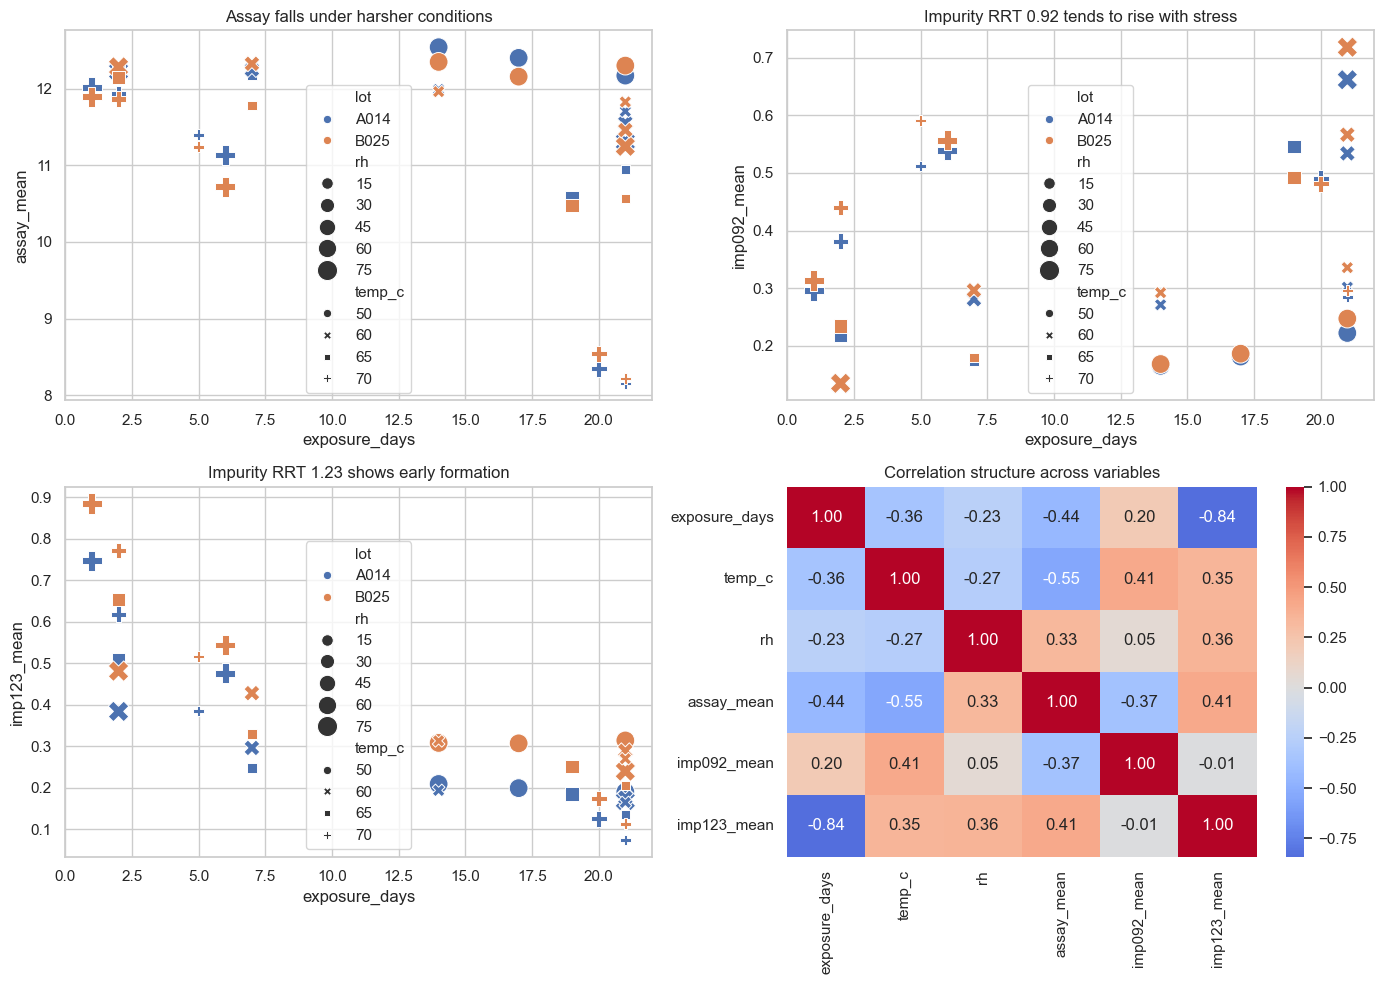

In [4]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.scatterplot(data=analysis_df, x='exposure_days', y='assay_mean', hue='lot', style='temp_c', size='rh', sizes=(60, 220), ax=axes[0,0])
axes[0,0].set_title('Assay falls under harsher conditions')
sns.scatterplot(data=analysis_df, x='exposure_days', y='imp092_mean', hue='lot', style='temp_c', size='rh', sizes=(60, 220), ax=axes[0,1])
axes[0,1].set_title('Impurity RRT 0.92 tends to rise with stress')
sns.scatterplot(data=analysis_df, x='exposure_days', y='imp123_mean', hue='lot', style='temp_c', size='rh', sizes=(60, 220), ax=axes[1,0])
axes[1,0].set_title('Impurity RRT 1.23 shows early formation')
heat_corr = analysis_df[['exposure_days','temp_c','rh','assay_mean','imp092_mean','imp123_mean']].corr()
sns.heatmap(heat_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1,1])
axes[1,1].set_title('Correlation structure across variables')
plt.tight_layout()
plt.show()


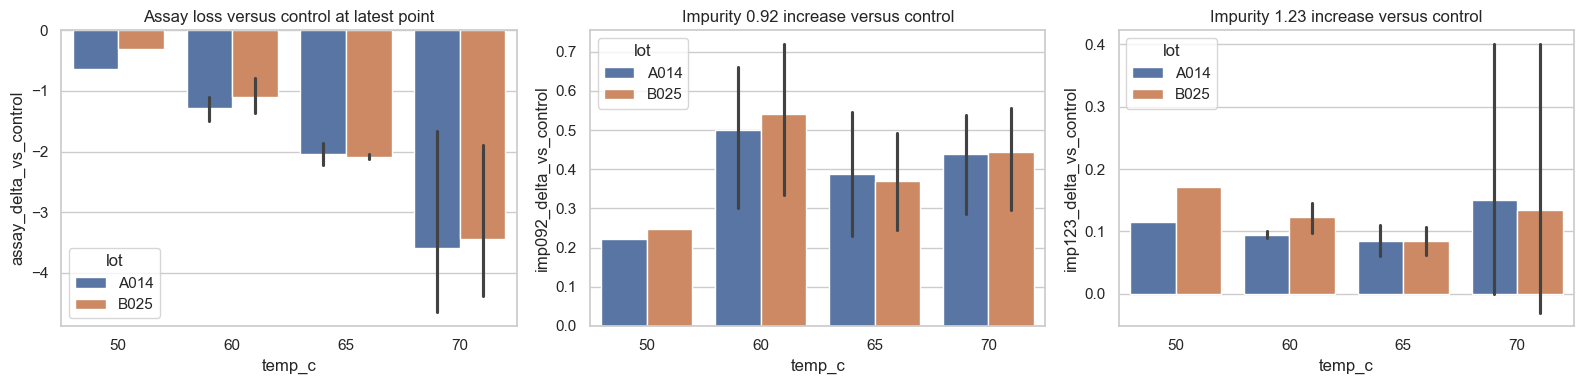

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
final_condition_df = analysis_df.sort_values('exposure_days').groupby(['lot','temp_c','rh']).tail(1)
sns.barplot(data=final_condition_df, x='temp_c', y='assay_delta_vs_control', hue='lot', ax=axes[0])
axes[0].set_title('Assay loss versus control at latest point')
sns.barplot(data=final_condition_df, x='temp_c', y='imp092_delta_vs_control', hue='lot', ax=axes[1])
axes[1].set_title('Impurity 0.92 increase versus control')
sns.barplot(data=final_condition_df, x='temp_c', y='imp123_delta_vs_control', hue='lot', ax=axes[2])
axes[2].set_title('Impurity 1.23 increase versus control')
plt.tight_layout()
plt.show()


## Key insights

The strongest pattern in the data is a loss of assay under more severe stress conditions, especially as exposure duration and temperature increase. The hottest conditions produce the lowest remaining assay values for both lots.

Impurity RRT 0.92 generally increases as stress becomes more severe. This relationship is not perfectly linear, but higher temperature, longer duration, and often higher humidity are associated with larger values.

Impurity RRT 1.23 behaves a little differently. It appears to form quickly under stress and can already be elevated at short exposure times, suggesting a faster or less linear degradation pathway than Impurity RRT 0.92.

Across the two formulations, the overall trends are very similar, which suggests both lots respond to the same underlying degradation drivers. However, B025 tends to show slightly higher impurity formation, particularly for Impurity RRT 1.23, which may indicate slightly weaker stability.

These findings are best interpreted as directional because the dataset is relatively small and each formulation is represented by only one lot. Even so, the visual and quantitative patterns are consistent enough to guide the next stage of development thinking.
